# Using matplotlib styles with mplchart

In [6]:
import yfinance as yf
import matplotlib.pyplot as plt

from mplchart.chart import Chart
from mplchart.primitives import Candlesticks, Volume
from mplchart.indicators import SMA, RSI, MACD
from mplchart.utils import normalize_prices

In [7]:
IGNORE = (("_", "seaborn"))
styles = [ s for s in plt.style.available
          if not s.startswith(IGNORE)]

styles

['Solarize_Light2',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'tableau-colorblind10']

In [8]:
ticker = "AAPL"
prices = normalize_prices(yf.Ticker(ticker).history(period="5y"))
prices.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1255 entries, 2021-08-02 00:00:00-04:00 to 2026-07-31 00:00:00-04:00
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   open          1255 non-null   float64
 1   high          1255 non-null   float64
 2   low           1255 non-null   float64
 3   close         1255 non-null   float64
 4   volume        1255 non-null   int64  
 5   dividends     1255 non-null   float64
 6   stock splits  1255 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 78.4 KB


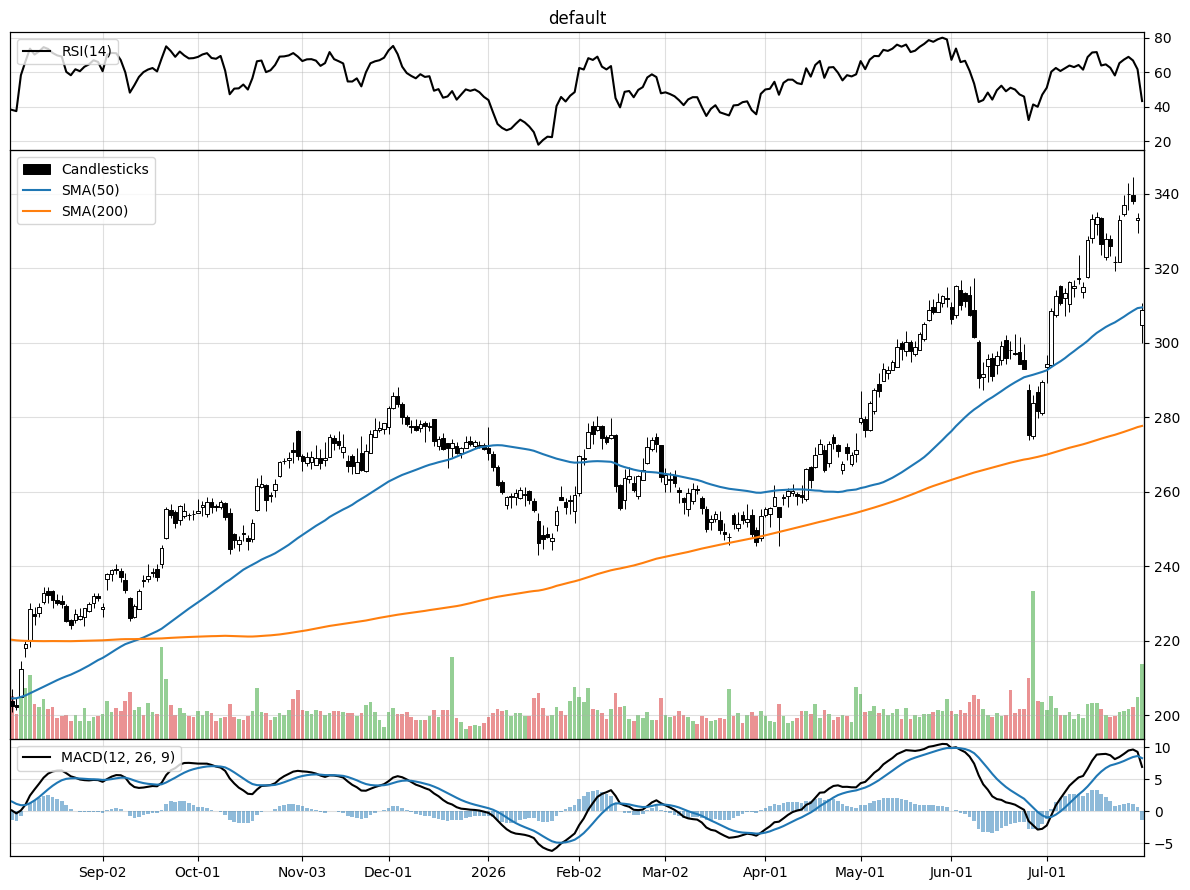

In [9]:
def plot_chart(prices, title="default", style=None):
    Chart(prices, title=title, max_bars=250, style=style).plot(
        Candlesticks(),
        SMA(50),
        SMA(200),
        Volume(),
    ).pane("above").plot(
        RSI()
    ).pane("below").plot(
        MACD()
    ).show()

plot_chart(prices)

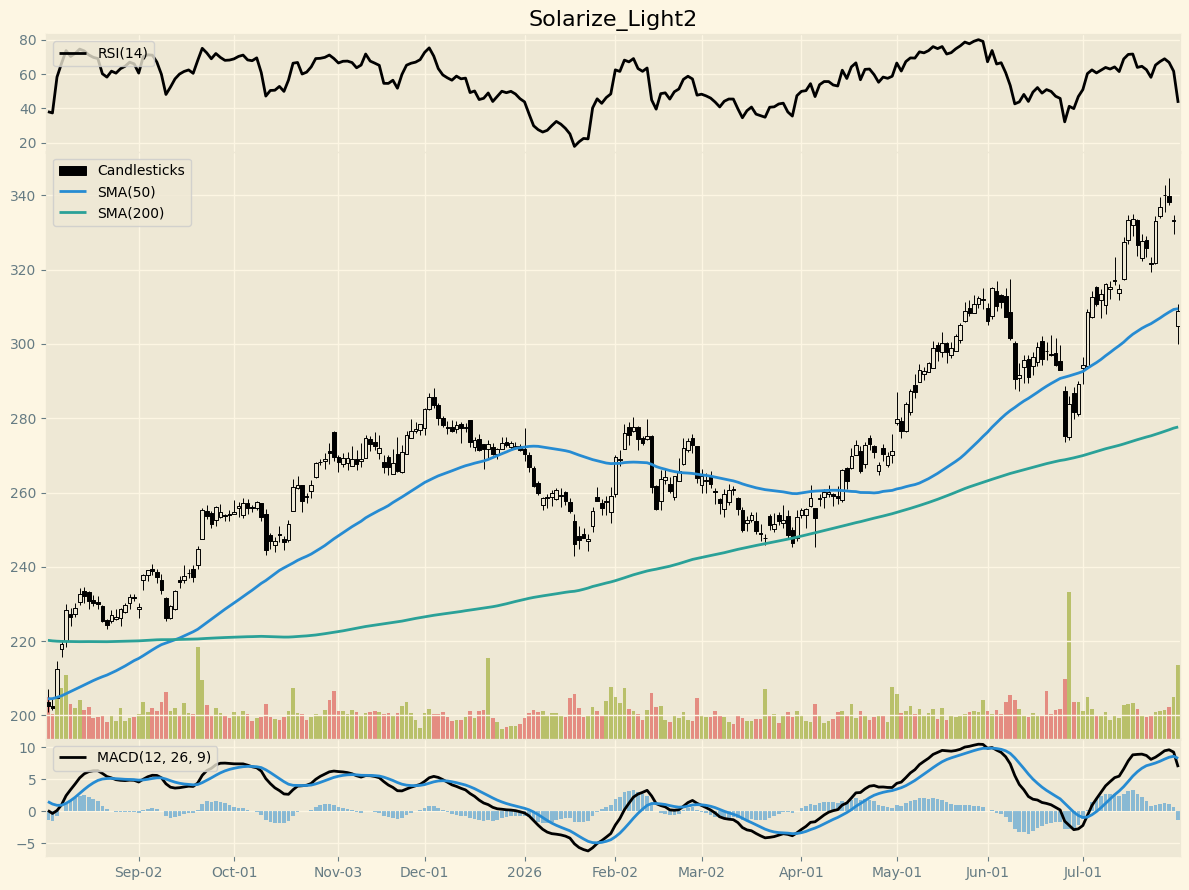

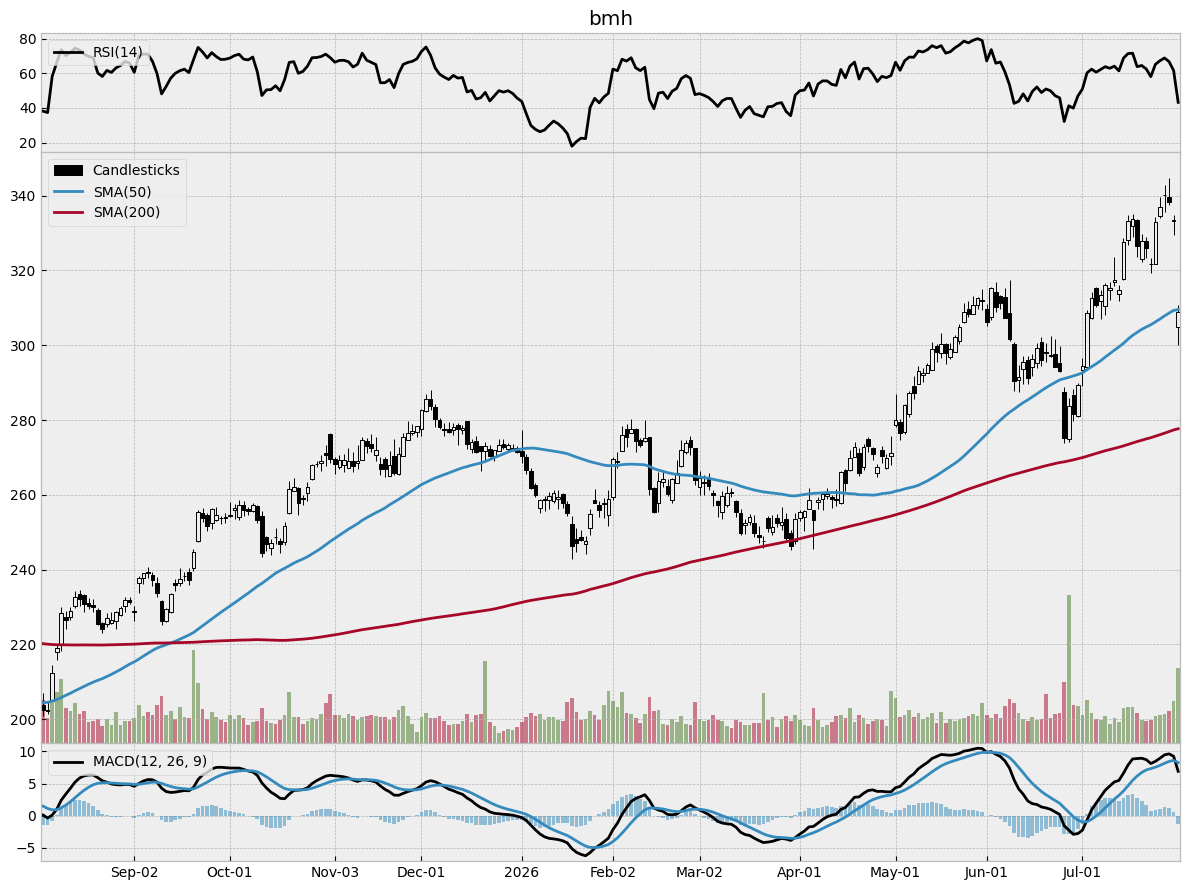

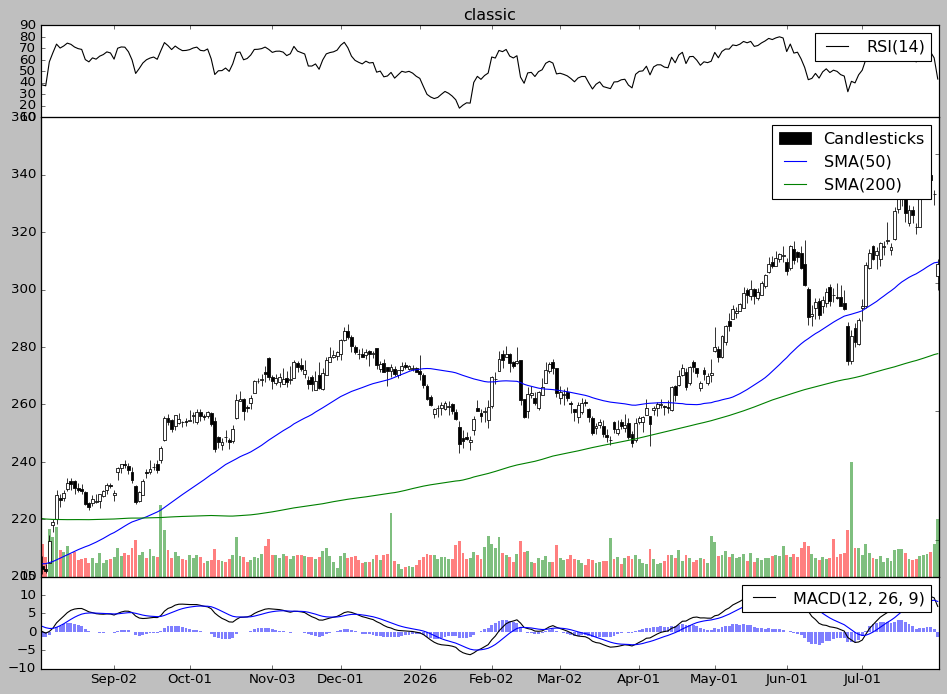

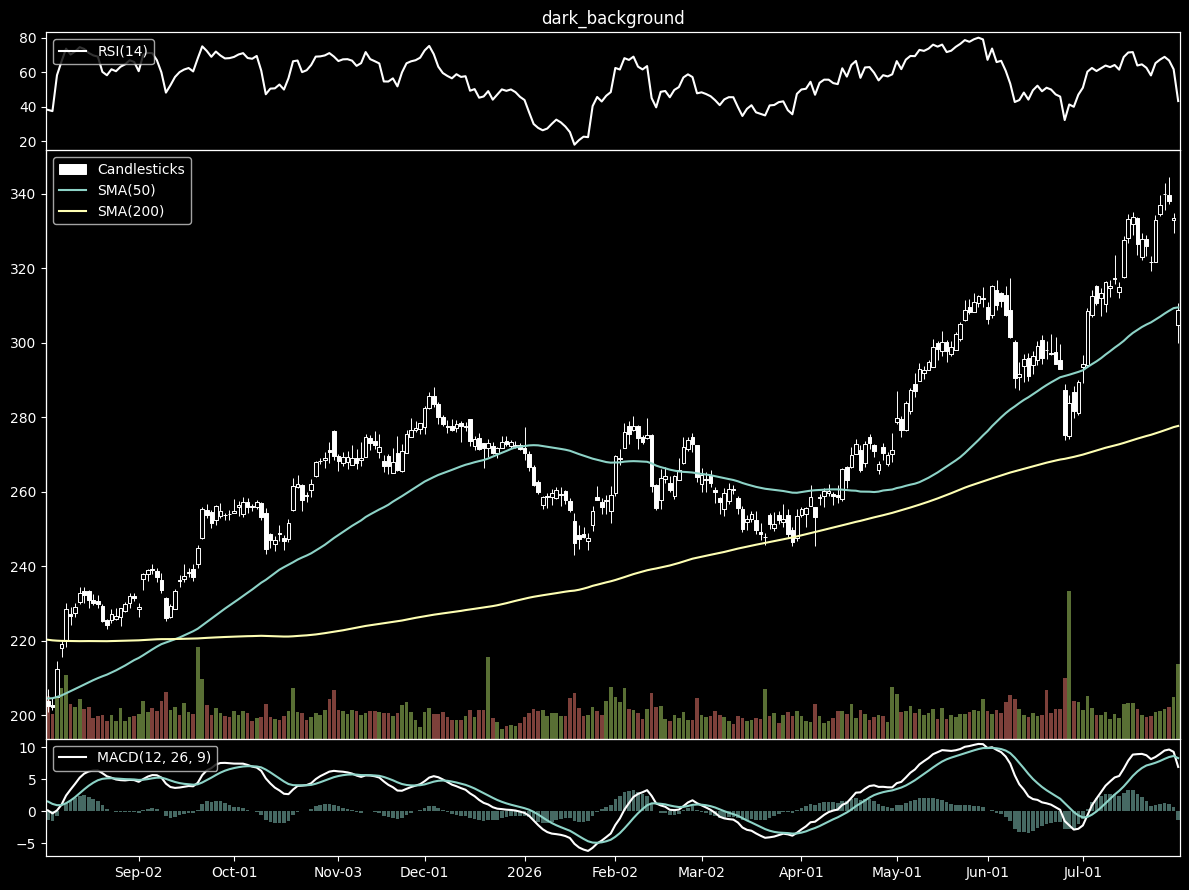

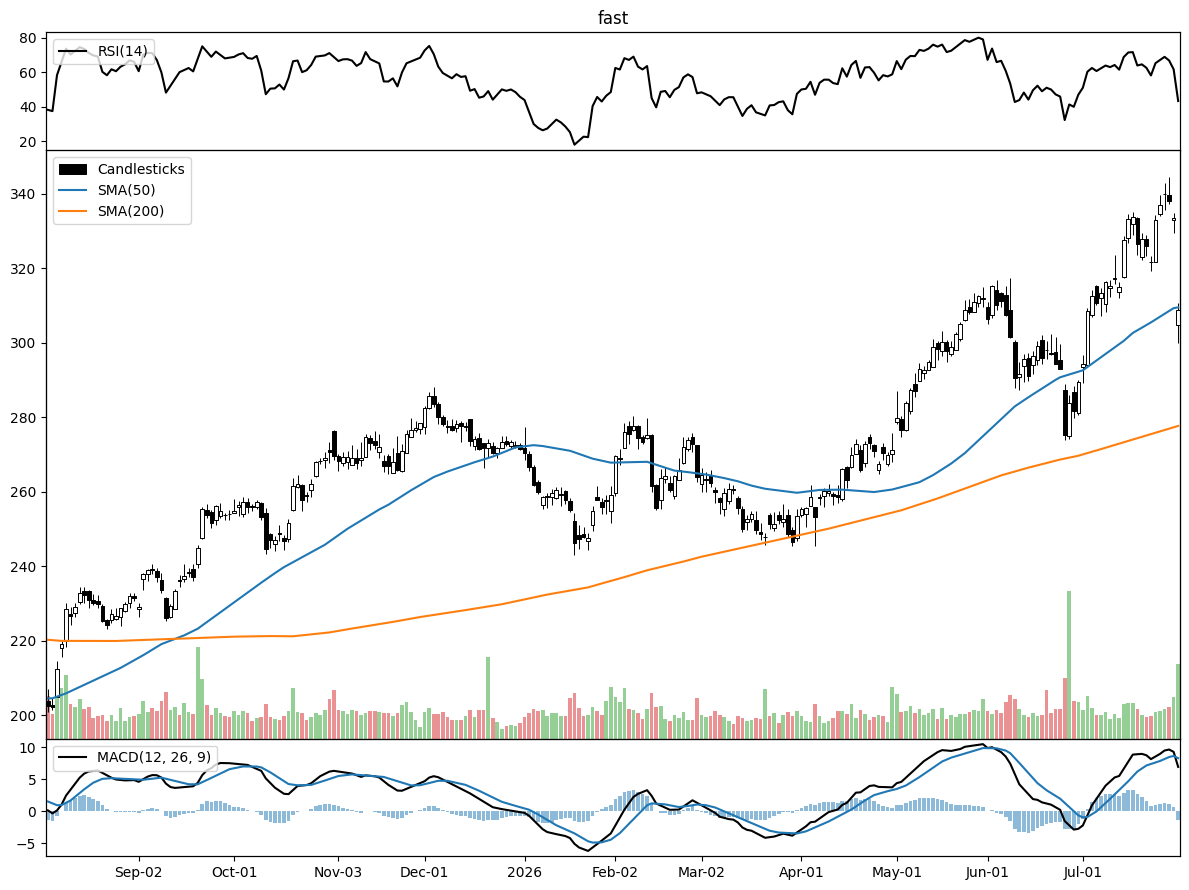

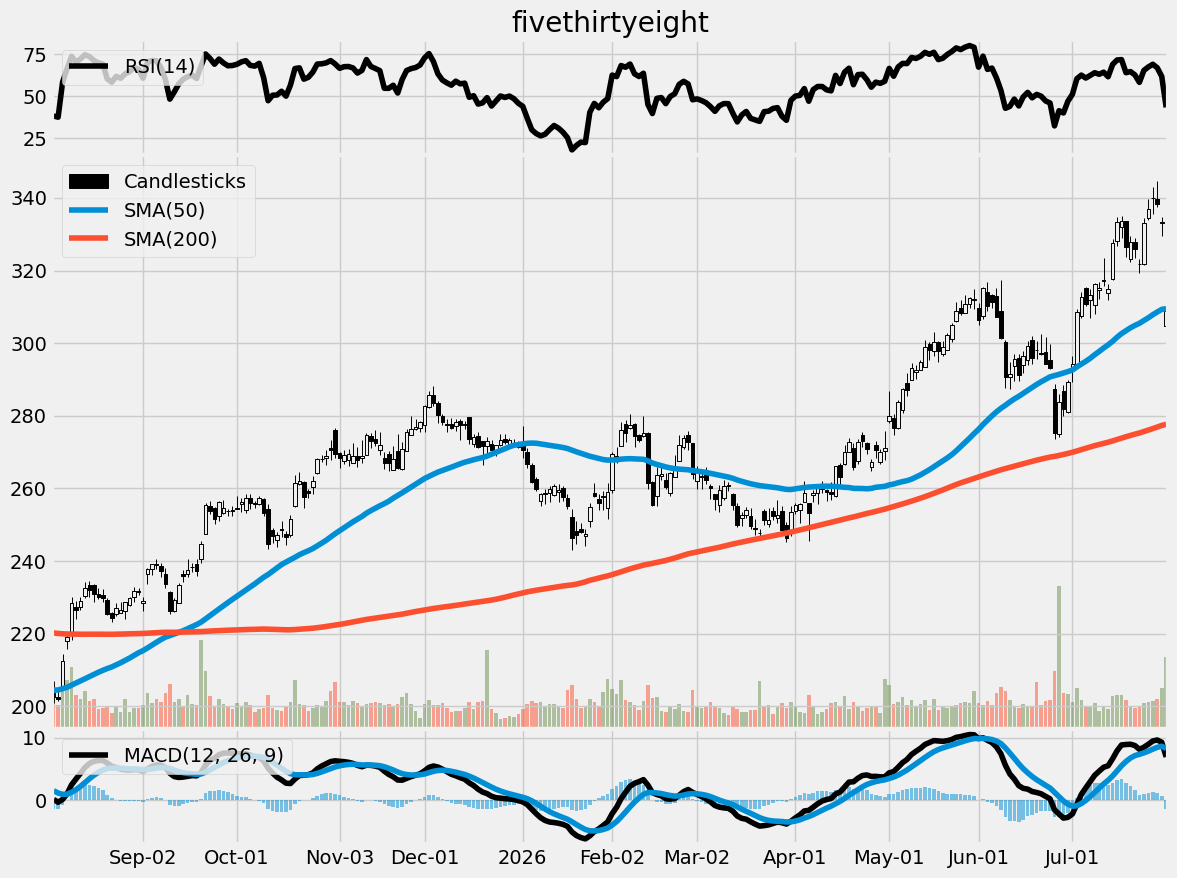

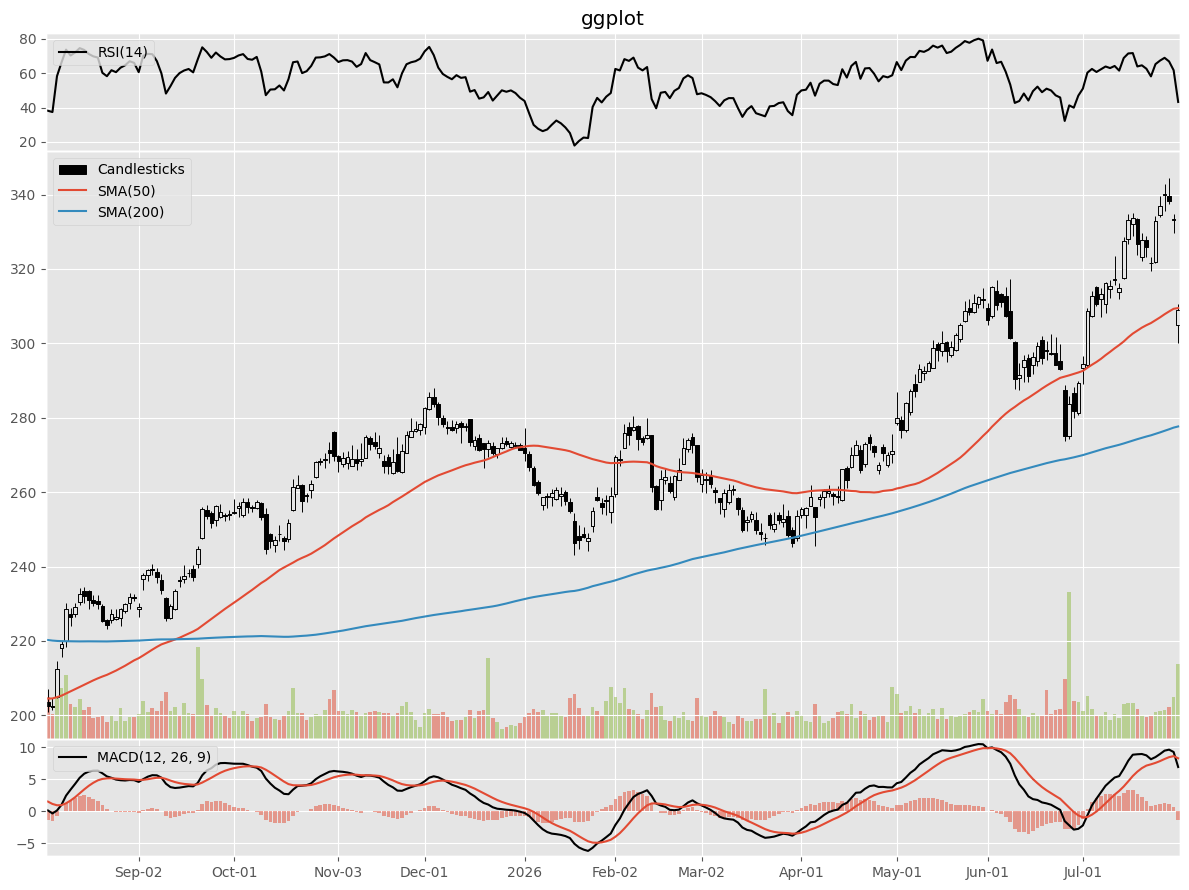

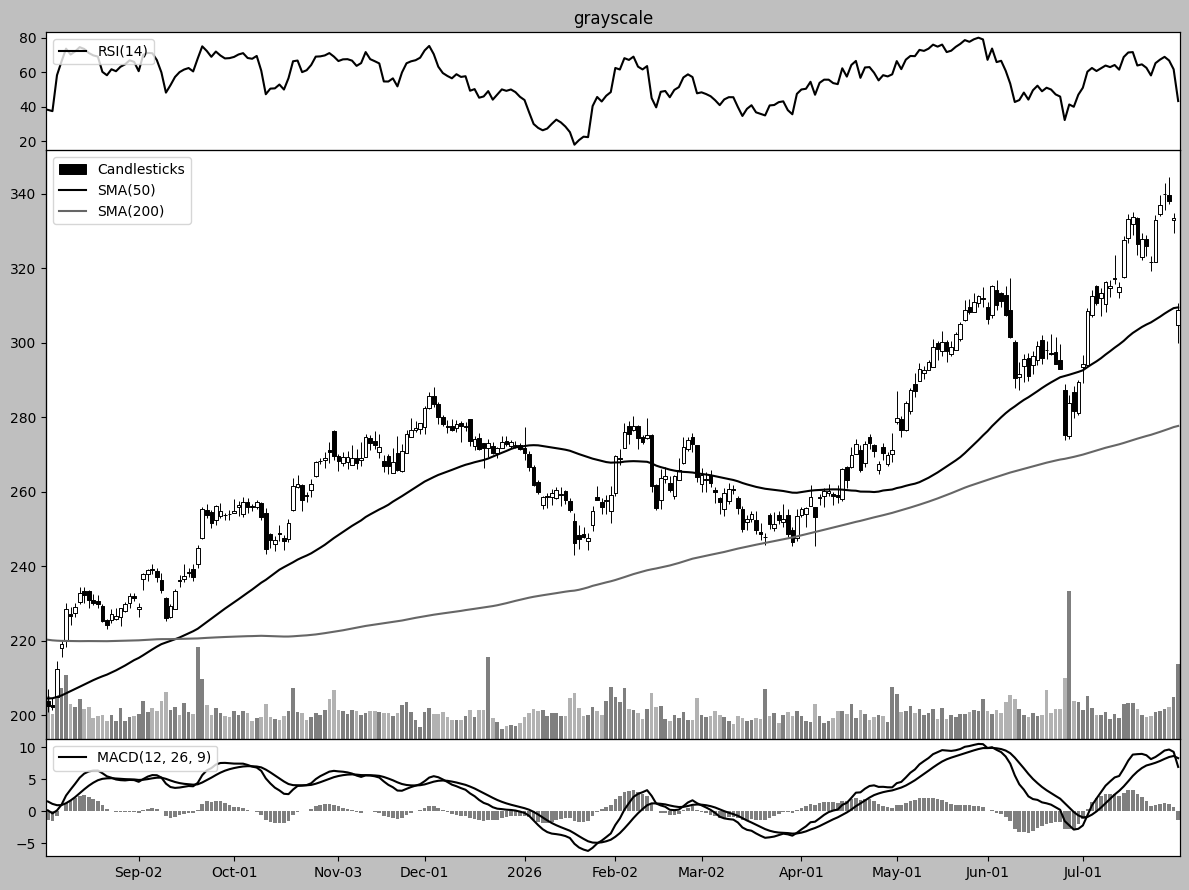

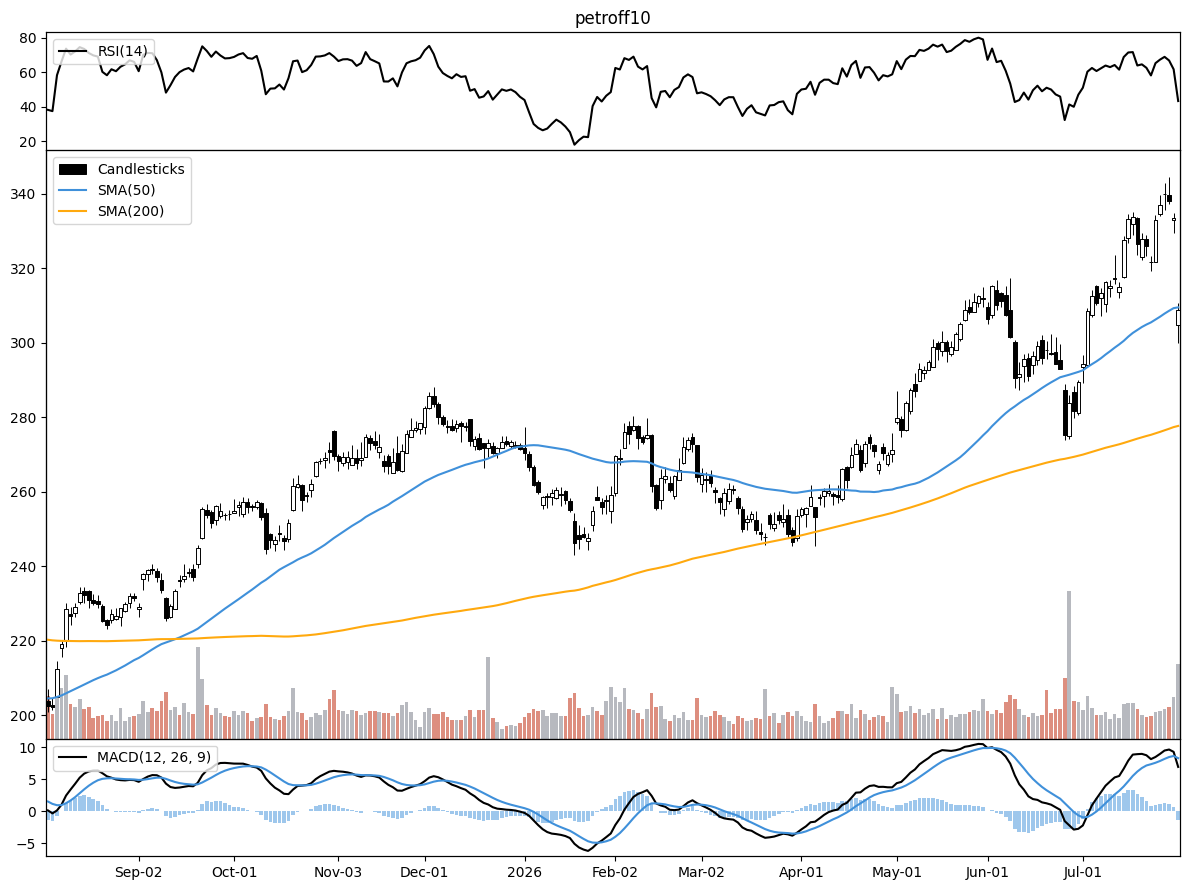

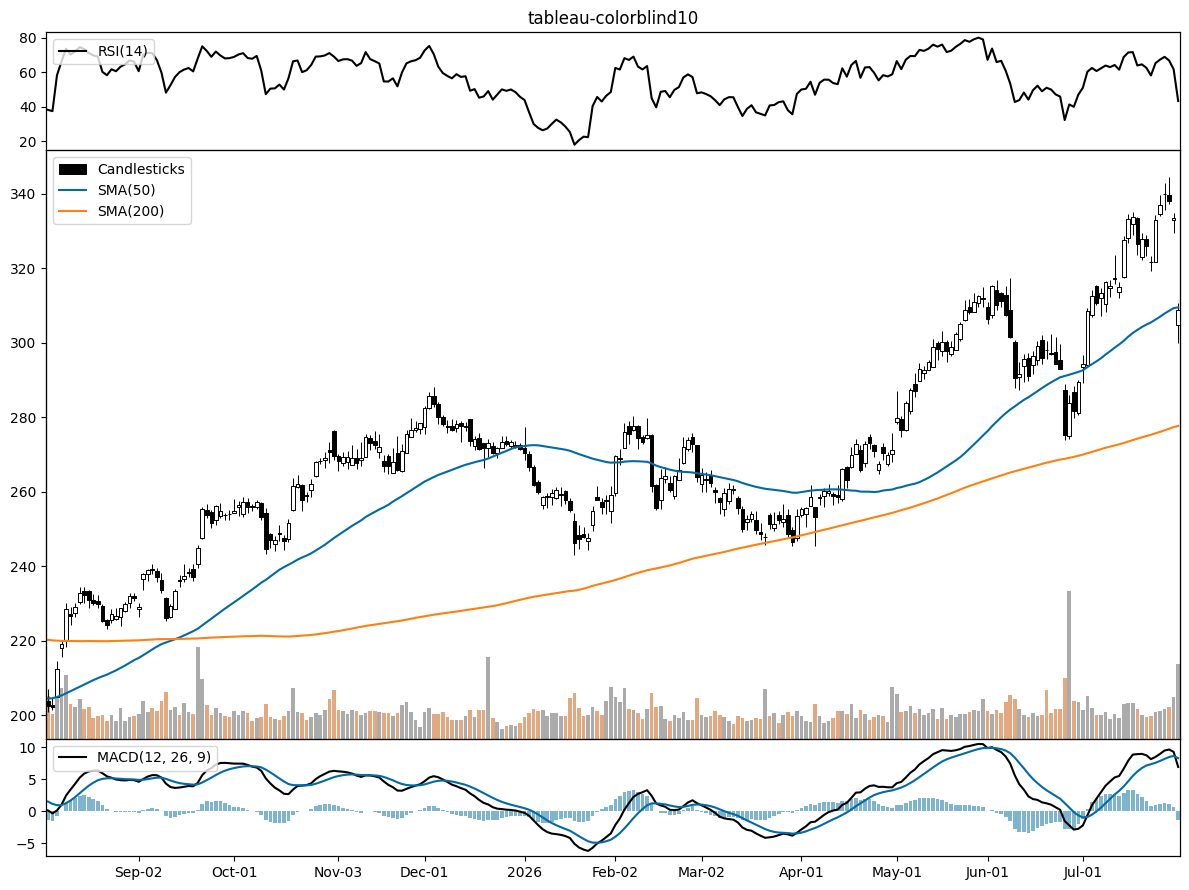

In [10]:
IGNORE = (("_", "seaborn"))
styles = [ s for s in plt.style.available
          if not s.startswith(IGNORE)]

for style in styles:
    plot_chart(prices, title=style, style=style)
